# 07 -- Per-cell heterogeneity of learned interaction kernels

The pooled fit (NB04) gives one kernel per condition.  Here we ask:

1. How variable are per-cell kernel fits?
2. Is the variability larger than bootstrap uncertainty from the pooled fit?
3. Does kernel variability correlate with measurable cell features (spindle
   length, chromosome count, observation window duration)?

This addresses whether "one force law per condition" is a good description
or whether there is biologically meaningful heterogeneity across cells.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from chromlearn import find_repo_root

ROOT = find_repo_root(Path(__file__).resolve().parent if "__file__" in dir() else Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from chromlearn.io.catalog import load_condition
from chromlearn.io.trajectory import (
    TrimmedCell,
    pole_center,
    spindle_frame,
    trim_trajectory,
)
from chromlearn.model_fitting import FitConfig
from chromlearn.model_fitting.fit import bootstrap_kernels, fit_model
from chromlearn.model_fitting.model import FittedModel
from chromlearn.model_fitting.plotting import plot_kernels
from chromlearn.model_fitting.simulate import simulate_cell

plt.rcParams["figure.dpi"] = 110

## Configuration

In [2]:
CONDITION = "rpe18_ctr"          # Control-condition cells used for the heterogeneity analysis.
FRAC_NEB_AO_WINDOW = 0.4         # Baseline trajectory window as a fraction of NEB-to-AO.
TOPOLOGY = "poles"               # Drift model carried over from the main selection notebook.
N_BASIS_XX = 10                  # Number of spline basis functions for chromosome-chromosome kernels.
N_BASIS_XY = 10                  # Number of spline basis functions for pole-chromosome kernels.
R_MIN = 0.3                      # Lower basis cutoff in microns.
R_MAX = 15.0                     # Upper basis cutoff in microns.
BASIS_TYPE = "bspline"           # Functional basis used for the learned kernels.
LAMBDA_RIDGE = 1e-3              # L2 penalty on coefficient magnitude.
LAMBDA_ROUGH = 1.0               # Smoothness penalty on neighboring spline coefficients.
BASIS_EVAL_MODE = "ito"          # Drift-evaluation convention used in the fit.
DT = 5.0                         # Frame interval in seconds.

## Load data and fit the pooled model

In [3]:
cells_raw = load_condition(CONDITION)
cells = [trim_trajectory(c, method="neb_ao_frac", frac=FRAC_NEB_AO_WINDOW) for c in cells_raw]
print(f"Loaded {len(cells)} {CONDITION} cells (trimmed to neb_ao_frac={FRAC_NEB_AO_WINDOW:.3f})")

config = FitConfig(
    topology=TOPOLOGY,
    n_basis_xx=N_BASIS_XX,
    n_basis_xy=N_BASIS_XY,
    r_min_xx=R_MIN,
    r_max_xx=R_MAX,
    r_min_xy=R_MIN,
    r_max_xy=R_MAX,
    basis_type=BASIS_TYPE,
    lambda_ridge=LAMBDA_RIDGE,
    lambda_rough=LAMBDA_ROUGH,
    basis_eval_mode=BASIS_EVAL_MODE,
    endpoint_method="neb_ao_frac",
    endpoint_frac=FRAC_NEB_AO_WINDOW,
    dt=DT,
)

pooled_model = fit_model(cells, config)
print(f"Pooled model: D = {pooled_model.D_x:.6f} um^2/s, "
      f"n_params = {pooled_model.theta.size}")

# Bootstrap for pooled uncertainty
boot = bootstrap_kernels(cells, config, n_boot=200, rng=np.random.default_rng(42))
print(f"Bootstrap: {boot.theta_samples.shape[0]} resamples")

Loaded 12 rpe18_ctr cells (trimmed to neb_ao_frac=0.400)


Pooled model: D = 0.001973 um^2/s, n_params = 10


Bootstrap: 200 resamples


## Per-cell fits

We fit each cell independently with the same config.  With ~46 chromosomes
and ~25-50 timepoints per cell, per-cell fits will be noisier than the
pooled fit, but the spread tells us about biological heterogeneity.

In [4]:
percell_models: list[FittedModel] = []
cell_metadata: list[dict] = []

for cell in cells:
    T, _, N = cell.chromosomes.shape
    m = fit_model([cell], config)
    percell_models.append(m)

    # Cell-level features
    pp_dist = np.linalg.norm(
        cell.centrioles[:, :, 1] - cell.centrioles[:, :, 0], axis=1
    )
    cell_metadata.append({
        "cell_id": cell.cell_id,
        "n_frames": T,
        "n_chromosomes": N,
        "duration_s": T * config.dt,
        "mean_spindle_length": float(np.nanmean(pp_dist)),
        "D_x": m.D_x,
    })
    print(f"  {cell.cell_id}: T={T}, N={N}, "
          f"spindle={pp_dist.mean():.2f} um, D={m.D_x:.6f}")

  rpe18_ctr_006: T=85, N=46, spindle=5.59 um, D=0.001296


  rpe18_ctr_032: T=93, N=46, spindle=6.46 um, D=0.001517


  rpe18_ctr_034: T=92, N=46, spindle=7.95 um, D=0.001351


  rpe18_ctr_035: T=96, N=46, spindle=10.01 um, D=0.001627


  rpe18_ctr_043: T=96, N=46, spindle=10.42 um, D=0.001159


...

  rpe18_ctr_500: T=127, N=46, spindle=10.71 um, D=0.001681


  rpe18_ctr_501: T=106, N=46, spindle=9.69 um, D=0.002812


  rpe18_ctr_502: T=110, N=46, spindle=11.23 um, D=0.002470


  rpe18_ctr_505: T=106, N=46, spindle=9.54 um, D=0.002848
  rpe18_ctr_506: T=96, N=46, spindle=11.43 um, D=0.002531


  rpe18_ctr_509: T=125, N=46, spindle=9.72 um, D=0.002231


## Overlay per-cell f_xy kernels on pooled fit

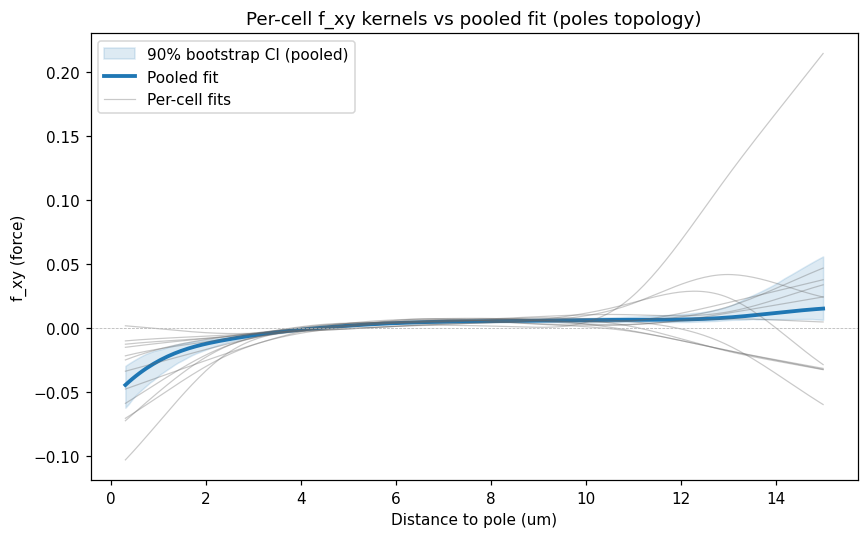

In [5]:
r_eval = np.linspace(config.r_min_xy, config.r_max_xy, 200)
phi_xy = pooled_model.basis_xy.evaluate(r_eval)

# Pooled kernel
pooled_fxy = phi_xy @ pooled_model.theta_xy

# Bootstrap CI
boot_xy_samples = boot.theta_samples[:, pooled_model.n_basis_xx:]
boot_curves = phi_xy @ boot_xy_samples.T
ci_lo = np.percentile(boot_curves, 5, axis=1)
ci_hi = np.percentile(boot_curves, 95, axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(r_eval, ci_lo, ci_hi, color="C0", alpha=0.15,
                label="90% bootstrap CI (pooled)")
ax.plot(r_eval, pooled_fxy, "C0", linewidth=2.5, label="Pooled fit")

for i, m in enumerate(percell_models):
    curve = phi_xy @ m.theta_xy
    ax.plot(r_eval, curve, color="0.4", alpha=0.35, linewidth=0.8,
            label="Per-cell fits" if i == 0 else None)

ax.axhline(0, color="0.7", linestyle="--", linewidth=0.5)
ax.set_xlabel("Distance to pole (um)")
ax.set_ylabel("f_xy (force)")
ax.set_title("Per-cell f_xy kernels vs pooled fit (poles topology)")
ax.legend()
fig.tight_layout()
plt.show()

## Summary statistics per cell

Extract scalar features from each per-cell kernel.  Sign convention:
positive f_xy = attractive (toward pole), negative = repulsive.

In [6]:
REF_DISTANCE = 5.0  # um

summary_rows = []
for i, (m, meta) in enumerate(zip(percell_models, cell_metadata)):
    curve = phi_xy @ m.theta_xy
    peak_attract = float(np.max(curve))
    peak_attract_loc = float(r_eval[np.argmax(curve)])
    ref_idx = np.argmin(np.abs(r_eval - REF_DISTANCE))
    ref_val = float(curve[ref_idx])
    summary_rows.append({
        **meta,
        "peak_attraction": peak_attract,
        "peak_attract_loc": peak_attract_loc,
        "f_xy_at_5um": ref_val,
    })

# Print table
print(f"{'Cell':<30} {'T':>4} {'N':>4} {'Spindle':>8} {'D':>10} "
      f"{'Peak attr':>10} {'Peak r':>8} {'f_xy@5um':>10}")
print("-" * 96)
for row in summary_rows:
    print(f"{row['cell_id']:<30} {row['n_frames']:>4} {row['n_chromosomes']:>4} "
          f"{row['mean_spindle_length']:>8.2f} {row['D_x']:>10.6f} "
          f"{row['peak_attraction']:>10.6f} {row['peak_attract_loc']:>8.2f} "
          f"{row['f_xy_at_5um']:>10.6f}")

Cell                              T    N  Spindle          D  Peak attr   Peak r   f_xy@5um
------------------------------------------------------------------------------------------------
rpe18_ctr_006                    85   46     5.59   0.001296   0.007234     7.98   0.001326
rpe18_ctr_032                    93   46     6.46   0.001517   0.007245     6.80   0.002105
rpe18_ctr_034                    92   46     7.95   0.001351   0.024260    15.00   0.002082
rpe18_ctr_035                    96   46    10.01   0.001627   0.033752    15.00   0.003593
rpe18_ctr_043                    96   46    10.42   0.001159   0.007064    13.15   0.002177
rpe18_ctr_049                    83   47     9.51   0.001698   0.006979     9.09   0.003534
rpe18_ctr_500                   127   46    10.71   0.001681   0.007914     9.24   0.003796
rpe18_ctr_501                   106   46     9.69   0.002812   0.028744    12.27  -0.000746
rpe18_ctr_502                   110   46    11.23   0.002470   0.046846    

## Correlations with cell features

Check whether per-cell kernel strength correlates with spindle length,
chromosome count, or observation window duration.

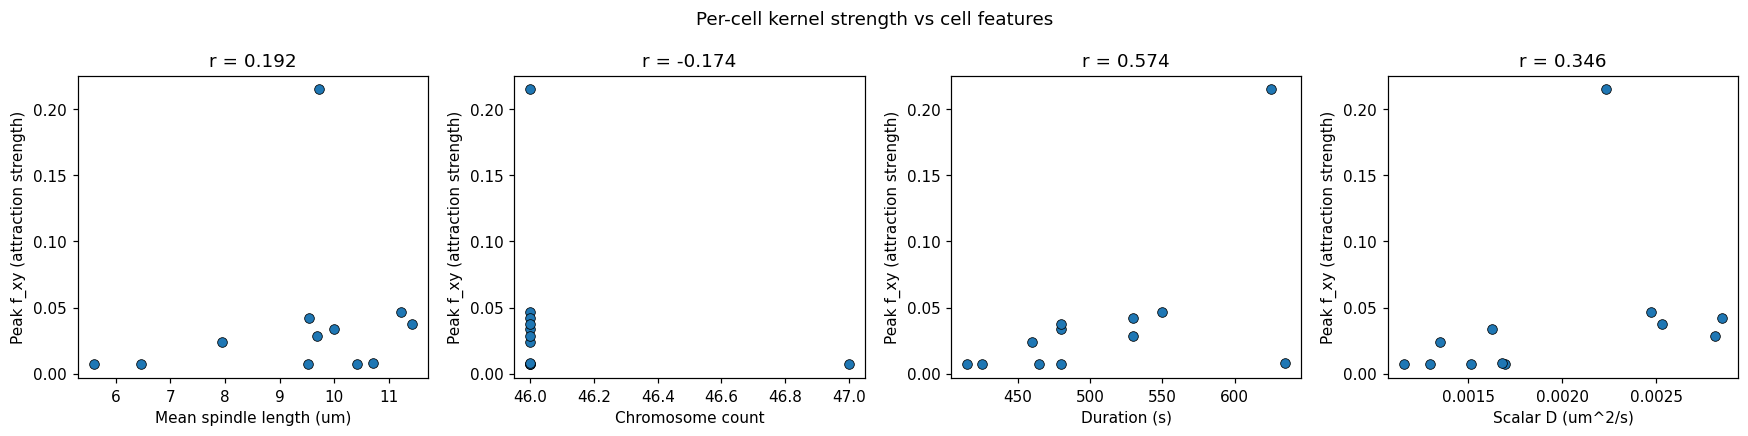

In [7]:
features = {
    "Mean spindle length (um)": [r["mean_spindle_length"] for r in summary_rows],
    "Chromosome count": [r["n_chromosomes"] for r in summary_rows],
    "Duration (s)": [r["duration_s"] for r in summary_rows],
    "Scalar D (um^2/s)": [r["D_x"] for r in summary_rows],
}
peak_vals = [r["peak_attraction"] for r in summary_rows]

fig, axes = plt.subplots(1, len(features), figsize=(4 * len(features), 4))
for ax, (feat_name, feat_vals) in zip(axes, features.items()):
    ax.scatter(feat_vals, peak_vals, s=40, color="C0", edgecolors="k", linewidths=0.5)
    # Simple correlation
    r_corr = float(np.corrcoef(feat_vals, peak_vals)[0, 1])
    ax.set_xlabel(feat_name)
    ax.set_ylabel("Peak f_xy (attraction strength)")
    ax.set_title(f"r = {r_corr:.3f}")

fig.suptitle("Per-cell kernel strength vs cell features")
fig.tight_layout()
plt.show()

## Rollout validation: pooled model on individual cells

For a few representative cells, simulate forward using the pooled model
and compare to real spindle-frame trajectories.

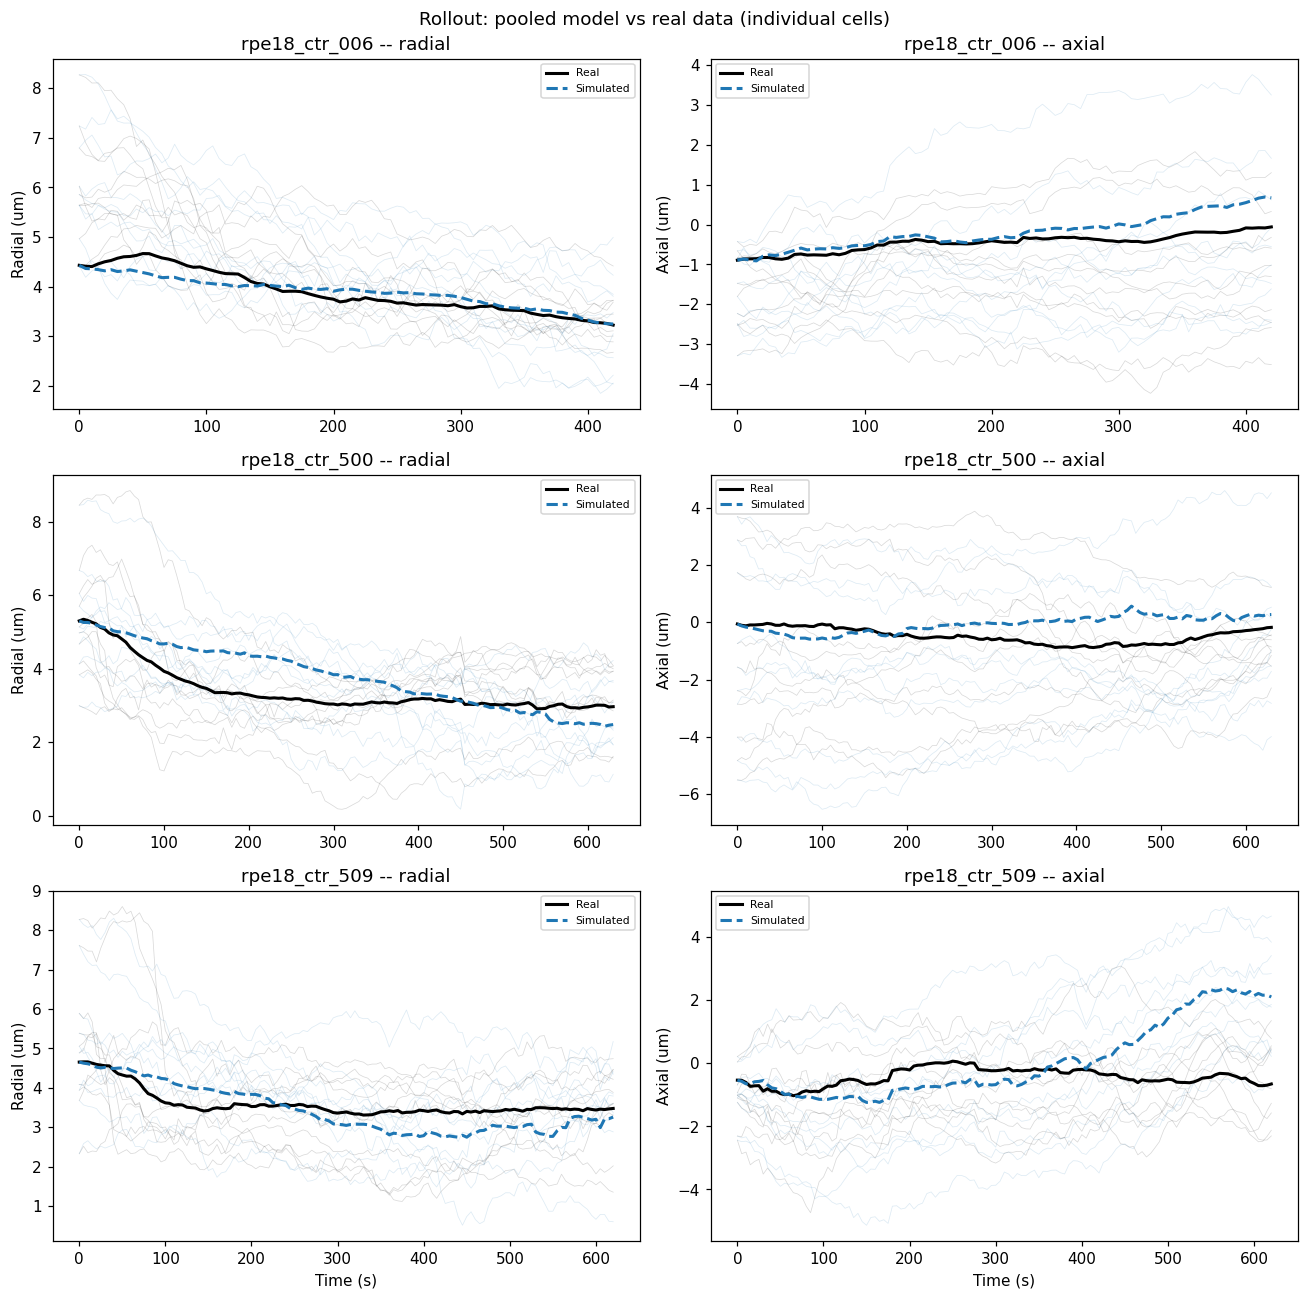

In [8]:
ROLLOUT_CELLS = [0, len(cells) // 2, len(cells) - 1]
fig, axes = plt.subplots(len(ROLLOUT_CELLS), 2, figsize=(12, 4 * len(ROLLOUT_CELLS)),
                         squeeze=False)

for row, cell_idx in enumerate(ROLLOUT_CELLS):
    cell = cells[cell_idx]
    T, _, N = cell.chromosomes.shape
    rng = np.random.default_rng(100 + cell_idx)
    _, sim_cell = simulate_cell(cell, pooled_model, rng=rng)

    sf_real = spindle_frame(cell)
    sf_sim = spindle_frame(sim_cell)
    time_axis = np.arange(T) * config.dt

    n_show = min(10, N)
    for i in range(n_show):
        axes[row, 0].plot(time_axis, sf_real.radial[:, i], "k-", alpha=0.15, linewidth=0.5)
        axes[row, 0].plot(time_axis, sf_sim.radial[:, i], "C0-", alpha=0.15, linewidth=0.5)
    axes[row, 0].plot(time_axis, np.nanmean(sf_real.radial, axis=1),
                      "k-", linewidth=2, label="Real")
    axes[row, 0].plot(time_axis, np.nanmean(sf_sim.radial, axis=1),
                      "C0--", linewidth=2, label="Simulated")
    axes[row, 0].set_ylabel("Radial (um)")
    axes[row, 0].set_title(f"{cell.cell_id} -- radial")
    axes[row, 0].legend(fontsize=7)

    for i in range(n_show):
        axes[row, 1].plot(time_axis, sf_real.axial[:, i], "k-", alpha=0.15, linewidth=0.5)
        axes[row, 1].plot(time_axis, sf_sim.axial[:, i], "C0-", alpha=0.15, linewidth=0.5)
    axes[row, 1].plot(time_axis, np.nanmean(sf_real.axial, axis=1),
                      "k-", linewidth=2, label="Real")
    axes[row, 1].plot(time_axis, np.nanmean(sf_sim.axial, axis=1),
                      "C0--", linewidth=2, label="Simulated")
    axes[row, 1].set_ylabel("Axial (um)")
    axes[row, 1].set_title(f"{cell.cell_id} -- axial")
    axes[row, 1].legend(fontsize=7)

axes[-1, 0].set_xlabel("Time (s)")
axes[-1, 1].set_xlabel("Time (s)")
fig.suptitle("Rollout: pooled model vs real data (individual cells)")
fig.tight_layout()
plt.show()

## Summary

**Key questions:**

1. Do per-cell kernels cluster tightly around the pooled fit, or is there
   wide spread?  If the spread exceeds the bootstrap CI, there is real
   cell-to-cell heterogeneity.
2. Do any cell features predict kernel strength?  If spindle length
   correlates with peak attraction, that connects the effective force to
   spindle geometry.
3. Does the pooled model produce reasonable rollouts for individual cells,
   or do some cells deviate strongly?

**Caveat:** Per-cell fits are noisy (each cell has ~46 chromosomes and
~25-50 timepoints), so the spread of per-cell curves confounds biological
heterogeneity with estimation noise.  The bootstrap CI on the *pooled*
fit only captures resampling uncertainty, not single-cell estimation noise.
A proper decomposition would require a hierarchical/shrinkage model.
This notebook is descriptive: it asks whether the pooled model is a
reasonable summary, not whether individual cells have truly different
force laws.